---
title: Sea Surface Temperature data from MESACLIP historical run
author: Frederic Castruccio, Chia-Wei Hsu
date: "2026-05-26"
---

# Access the MESACLIP Oceanic and Atmospheric Data

## Required Packages

Please ensure the following packages are installed before proceeding.

| Category                   | Package      | Purpose |
|---                         |---           |---|
| **Data Access & Analysis** | `kerchunk`   | Read the virtualized-zarr format data |
|                            | `xarray`     | Lazy loading and array manipulation |
| **Visualization**          | `matplotlib` | General-purpose plotting |
|                            | `folium`     | python interface to generate the leaflet map |

## Step 1 - Read the data in the ARCO format
The original data are stored in NetCDF files, organized by ensemble member, model component (`ocn`, `atm`, etc.), temporal frequency (`day_1`, `month_1`), and variable-specific files. Accessing one variable across the full time range may require opening roughly 10–20 files, and accessing two variables may require 20–40 files. This can be time-consuming, even when using `xarray.open_mfdataset`. In addition, when subsetting data, xarray must inspect the NetCDF structure to locate chunk positions.  
With ARCO (virtualized Zarr), chunk byte ranges are pre-indexed in JSON/dictionary references. This provides modest speedups for local access and much faster response for remote access (for example, via HTTP requests).

## Step 2 - Locate the Dataset

The dataset is freely available on the [NCAR GDEX portal](https://gdex.ucar.edu/datasets/d651007/) and is stored on NCAR's Campaign storage. This notebook demonstrates two access methods:

- **NCAR HPC** — direct Campaign Storage access for users on NCAR's HPC systems
- **Remote** — internet-based access for users outside of NCAR


In [1]:
campaign_store_posix = "/gdex/data/d651007/kerchunk/b.e13.BHISTC5.ne120_t12.cesm-ihesp-hires1.0.46-1920-2005.010.ocn.day_1.parq"
campaign_store_remote = "https://data.gdex.ucar.edu/d651007/kerchunk/b.e13.BHISTC5.ne120_t12.cesm-ihesp-hires1.0.46-1920-2005.010.ocn.day_1-remote-osdf.parq"

## Step 3 - Open the Data

`xr.open_dataset` integrates well with the Python `kerchunk` engine, making it straightforward to open a reference file such as `.json` or `.parq`. In this workflow, the dataset is stored as a single kerchunk reference file that combines all variables and the full time range for a given ensemble member, model component, and temporal frequency. As a result, users only need to open one reference file to access all available variables and time slices from the original model output.

:::{note} Memory usage
This notebook also includes a brief demonstration of how a kerchunk reference file enables loading only the required data chunks, rather than the entire dataset, by monitoring memory usage throughout the workflow. The following block is to print out the current memory usage by the cells that was executed before the print statement `Notebook process memory.....`
:::

In [2]:
import os
import psutil
# check the memory usage of the current notebook process only
process = psutil.Process(os.getpid())
mem_info = process.memory_info()
print(f"Notebook process memory usage: {mem_info.rss / (1024 ** 3):.2f} GB (RSS)")

Notebook process memory usage: 0.04 GB (RSS)


In [3]:
import xarray as xr
ds = xr.open_dataset(campaign_store_posix, engine="kerchunk",decode_timedelta=False, chunks={})

In [4]:
import os
import psutil
# check the memory usage of the current notebook process only
process = psutil.Process(os.getpid())
mem_info = process.memory_info()
print(f"Notebook process memory usage: {mem_info.rss / (1024 ** 3):.2f} GB (RSS)")

Notebook process memory usage: 2.65 GB (RSS)


In [5]:
print(ds.nbytes / 1024**4, "TB")

67.092546539654 TB


:::{note} Memory usage
As shown above, the notebook process memory increases from about ~0.1 GB to about ~3.00 GB after calling `xr.open_dataset`. This indicates that `open_dataset` is primarily opening the kerchunk reference file, which acts as a lookup table for variables, chunks, and time slices, rather than loading the full dataset into memory.

In contrast, the full dataset size is approximately 67 TB, as printed above. This demonstrates the main advantage of the reference-based ARCO workflow: users can query any variable at any time slice through a single reference file without first locating and opening many individual NetCDF files. In practice, this significantly streamlines and speeds up the preprocessing stage.
:::

## Step 4 - Focus on a Single Time Slice

Next, load only a single time slice of one variable to demonstrate selective data access. This step shows that, although the full dataset is very large, only the requested subset is brought into memory when `.load()` is called.

In the following example, the notebook selects sea surface temperature (`SST`) at one time index and loads that 2D field into memory for analysis and plotting. After that, memory usage is checked again to show the additional cost of loading just this subset rather than the full dataset.

This illustrates a key advantage of the kerchunk-based ARCO workflow: data can remain lazily referenced until a specific variable and time slice are explicitly requested.


In [6]:
da_sst = ds['SST'].isel(time=1030).load()


In [8]:
# the grid is assumed unchanged and can be loaded in the first time step and reused for all time steps
da_lat = ds['TLAT'].isel(time=0).load()
da_lon = ds['TLONG'].isel(time=0).load()

In [9]:
import os
import psutil
# check the memory usage of the current notebook process only
process = psutil.Process(os.getpid())
mem_info = process.memory_info()
print(f"Notebook process memory usage: {mem_info.rss / (1024 ** 3):.2f} GB (RSS)")

Notebook process memory usage: 8.88 GB (RSS)


In [10]:
ds_sst = xr.Dataset()
ds_sst['SST'] = da_sst
ds_sst['TLONG']= da_lon
ds_sst['TLAT'] = da_lat

In [11]:
ds_sst = ds_sst.expand_dims('time')

In [12]:
ds_sst

<xarray.Dataset> Size: 311MB
Dimensions:  (nlat: 2400, nlon: 3600, time: 1)
Coordinates:
    TLAT     (nlat, nlon) float64 69MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    TLONG    (nlat, nlon) float64 69MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    ULAT     (nlat, nlon) float64 69MB nan nan nan nan nan ... nan nan nan nan
    ULONG    (nlat, nlon) float64 69MB nan nan nan nan nan ... nan nan nan nan
  * time     (time) object 8B 1922-10-29 00:00:00
Dimensions without coordinates: nlat, nlon
Data variables:
    SST      (time, nlat, nlon) float32 35MB -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0

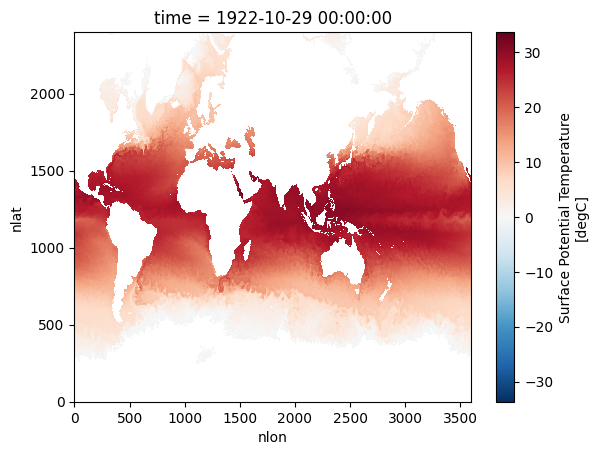

In [13]:
ds_sst['SST'] = ds_sst['SST'].where(ds_sst['SST'].compute()>-1)
ds_sst['SST'].plot()

In [14]:
import os
import psutil
# check the memory usage of the current notebook process only
process = psutil.Process(os.getpid())
mem_info = process.memory_info()
print(f"Notebook process memory usage: {mem_info.rss / (1024 ** 3):.2f} GB (RSS)")

Notebook process memory usage: 9.39 GB (RSS)


:::{tip} Load a single time slice

The notebook process memory increased from about 4 GB to 6.62 GB after calling `.load()` on one sea surface temperature (`SST`) time slice. This shows that only the requested 2D sea surface temperature field was loaded into memory for analysis and plotting, while the rest of the dataset remained lazily referenced.
:::

## Step 5 - Remap the data using regrid weight file

Preprocessed by NCAR scientist, Frederic Castruccio, the file that one needs to load to perform the regridding of the ocean data from 

In [17]:
import fsspec
import xarray as xr

# the netcdf file is available to download at this URL, but xarray cannot read it directly.
# So we use fsspec to open the file as a binary stream through https, and then pass that stream to xarray. 
# This works because the xarray can read from file-like objects created by the fsspec library.
wgtfile_url = "https://data.gdex.ucar.edu/d651007/remap/POP_tx0.1v2_to_latlon_1x1_0E_bilinear_20251113.nc"
f = fsspec.open(wgtfile_url, mode="rb").open()
dsw = xr.open_dataset(f)

In [18]:
import numpy as np
import scipy.sparse as sps
from netCDF4 import default_fillvals

def remap_pop(ds, dsw, varlst):
    """Remap variables from the POP curvilinear ocean grid to a regular lat/lon grid.

    Caution!!!
    current version of ds assume the time dimension exists. (sometime xarray .isel(time=0) will drop the time dimension)

    Uses precomputed ESMF bilinear weights (dsw) via sparse matrix multiplication,
    then corrects remapped values for partial land coverage near coastlines.

    Parameters
    ----------
    ds : xarray.Dataset
        xarray.Dataset on the source POP grid (nlat x nlon)
    dsw : xarray.Dataset
        xarray.Dataset containing ESMF regridding weights (row, col, S)
    varlst : list
        list of variable names in ds to remap

    Returns
    -------
    dso : xarray.Dataset
        xarray.Dataset on a regular lat/lon grid
    """
    # Initialize the output dataset with NaN
    dso = xr.full_like(ds.drop_dims('nlat'), np.nan)

    # Extract source and destination grid coordinates from the weight file
    # srclon/srclat are kept for reference but not used in the sparse multiply
    srclon = dsw.xc_a.values.reshape([dsw.src_grid_dims[1].values, dsw.src_grid_dims[0].values])
    srclat = dsw.yc_a.values.reshape([dsw.src_grid_dims[1].values, dsw.src_grid_dims[0].values])
    dstlon = dsw.xc_b.values.reshape([dsw.dst_grid_dims[1].values, dsw.dst_grid_dims[0].values])[0]
    dstlat = dsw.yc_b.values.reshape([dsw.dst_grid_dims[1].values, dsw.dst_grid_dims[0].values])[:,0]

    # Build the sparse weight matrix (n_dst × n_src); ESMF row/col indices are 1-based
    weights = sps.coo_matrix((dsw.S, (dsw.row-1, dsw.col-1)), shape=[dsw.sizes['n_b'], dsw.sizes['n_a']])

    for varname in varlst:
        shape_in = ds[varname].shape
        shape_out = dsw.dst_grid_dims.values[1], dsw.dst_grid_dims.values[0]

        # Derive the ocean/land mask from the first time slice (True = land/missing)
        srcmask = np.isnan(ds[varname].isel(time=0))

        # Flatten source data to (n_time, n_src) for the sparse multiply; NaNs replaced with 0
        srcvar_flat = ds.fillna(0)[varname].values.reshape(-1, shape_in[-2]*shape_in[-1])
        # Flatten the valid-ocean boolean mask to (n_src,) (True = ocean)
        srcmask_flat = np.invert(srcmask).values.reshape(shape_in[-2]*shape_in[-1])

        # Apply bilinear weights to the data → (n_time, n_dst)
        remapped_flat = weights.dot(srcvar_flat.T).T
        # Apply the same weights to the mask to track fractional ocean coverage per destination cell
        remapped_mask_flat = weights.dot(srcmask_flat.T).T

        remapped = remapped_flat.reshape([*shape_in[0:-2], shape_out[0], shape_out[1]])
        remapped_mask = remapped_mask_flat.reshape([shape_out[0], shape_out[1]])

        # Clamp zero-coverage cells to 1 to avoid division by zero for fully-land destinations
        remapped_mask[np.where(remapped_mask==0)] = 1
        # Normalize by fractional ocean coverage to remove land contamination near coastlines
        remapped = remapped / remapped_mask[None,:,:]
        # Mark fully-land destination cells as the standard fill value
        remapped[np.where(remapped==0)] = default_fillvals['f8']

        # Rebuild dimension and coordinate mappings for the output DataArray
        dimlst = list(ds[varname].dims[0:-2])
        dims={}
        coords={}
        for it in dimlst:
            dims[it] = dso.dims[it]
            coords[it] = dso.coords[it]
        dims['lat'] = int(dsw.dst_grid_dims[1])
        dims['lon'] = int(dsw.dst_grid_dims[0])
        coords['lat'] = (['lat'], dstlat)
        coords['lon'] = (['lon'], dstlon)
        remapped = xr.DataArray(remapped, coords=coords, dims=dims, attrs=ds[varname].attrs)
        remapped['lat'].attrs = {'units':'degrees_north'}
        remapped['lon'].attrs = {'units':'degrees_east'}
        dso = xr.merge([dso, remapped.to_dataset(name=varname)])
    return dso

### Apply the Regridding

Call `remap_pop` to project `SST` from the native curvilinear POP grid (2400 × 3600 `nlat`/`nlon`) onto a regular 1° × 1° lat/lon grid using the precomputed ESMF bilinear weights. The `%%time` magic records the wall-clock time of the operation. Because the remapping is a single sparse matrix multiplication, it completes in well under a second even for a global 2D field. The result is stored in `dso`, an `xarray.Dataset` with standard `lat` and `lon` coordinates, ready for plotting or further analysis.

In [19]:
%%time
dso = remap_pop(ds_sst, dsw, ['SST'])

CPU times: user 154 ms, sys: 63.9 ms, total: 218 ms
Wall time: 234 ms


/glade/derecho/scratch/chiaweih/tmp/ipykernel_12482/782792240.py:73: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims[it] = dso.dims[it]


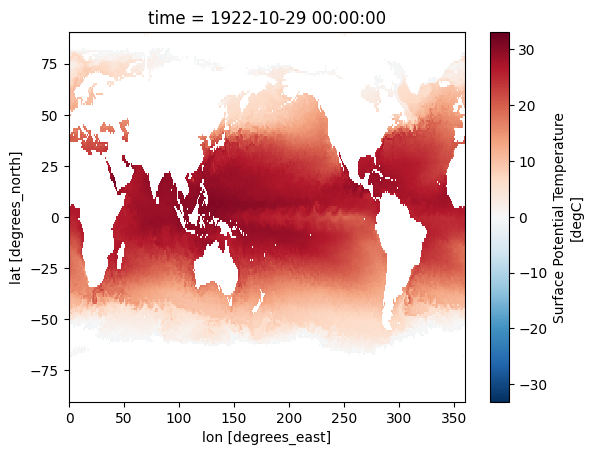

In [20]:
dso['SST'].where(dso['SST']!=default_fillvals['f8']).isel(time=0).plot()

## Step 6 - Visualize the Regridded Data on an Interactive Map

### 6a — Reorder Longitudes from [0°, 360°) to [−180°, 180°)

Folium and rioxarray both expect longitudes in the standard geographic convention of [−180°, 180°]. The ESMF regridding output inherits the POP grid's [0°, 360°) convention. This cell converts to the signed convention by shifting each longitude value with `(lon + 180) % 360 - 180`, then calls `sortby("lon")` to restore monotonic ordering — a requirement for correct raster rendering.

In [21]:
# Reorder the longitude to be in the range of [-180, 180] for rioxarray and folium compatibility
dso = dso.assign_coords(lon=(((dso.lon + 180) % 360) - 180)).sortby("lon")

### 6b — Reproject to Web Mercator (EPSG:3857)

Folium's tile layers use the Web Mercator projection (EPSG:3857), the same projection used by Google Maps and OpenStreetMap. To overlay a raster image accurately on those tiles, the data must be warped from its native WGS84 geographic coordinates (EPSG:4326) into Web Mercator before being passed to Folium.

This cell uses `rioxarray` to:
1. Detect the spatial dimension names (`lon`/`lat`).
2. Declare the original CRS as EPSG:4326 with `.write_crs()`.
3. Reproject the SST field to EPSG:3857 with `.reproject()`, preserving the original output grid shape.

In [22]:
# Use the .rio accessor to set spatial dimensions and CRS for reprojection to Web Mercator (EPSG:3857)
import rioxarray  # must import to activate .rio accessor
da = dso["SST"]

# Check actual dimension names
lon_dim = [d for d in da.dims if "lon" in d.lower() or d.lower() == "x"][0]
lat_dim = [d for d in da.dims if "lat" in d.lower() or d.lower() == "y"][0]

# Set spatial dims
da = da.rio.set_spatial_dims(x_dim=lon_dim, y_dim=lat_dim)

# Assigne the original CRS (original data is in WGS84 lat/lon)
da = da.rio.write_crs("EPSG:4326")

# Verify CRS was set
print("original CRS:", da.rio.crs)

# Now reproject
da_sst_merc = da.rio.reproject("EPSG:3857",shape=(da.shape[-2], da.shape[-1]))

original CRS: EPSG:4326


### 6c — Build and Display the Folium Interactive Map

This cell assembles the interactive Leaflet map using `folium` and `branca`. The steps are:

1. **Colormap** — a matplotlib colormap (`RdBu_r`) is applied to the normalized SST values (clipped to `[varmin, varmax]`) to produce an RGBA image array.
2. **Base map** — a `folium.Map` is created centered on the data domain with a light `CartoDB Positron` tile layer.
3. **Image overlay** — the RGBA array is added as a `folium.raster_layers.ImageOverlay`. `mercator_project=False` because the data is already in Web Mercator; `origin="upper"` ensures rows are drawn from the top of the bounding box downward.
4. **Color bar legend** — a `branca.LinearColormap` is added to the map with the variable name as its caption.
5. **Title** — an HTML `<h1>` element is injected into the map root to display the dataset label.

Run the next cell (`fm`) to render the interactive map inline.

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import folium
import branca.colormap as cm
from branca.element import Template, MacroElement

# figure setting
colormap_name = 'RdBu_r'              # colormap name in matplotlib colormap blue to red
n_increments = 33                     # number of increment in the colormap
varmin = 0                           # minimum value on the colorbar
varmax = 32                            # maximum value on the colorbar
varname = 'SST (sea surface temperature)'        # legend show on map
da_regrid_data = da_sst_merc.isel(time=0) # Xarray DataArray object used to plot the map
da_regrid_data = da_regrid_data.where(da_regrid_data!=default_fillvals['f8'], np.nan) # make sure NaN values are properly set for plotting


# setup the colormap from matplotlib
picked_cm = plt.get_cmap(colormap_name, n_increments)
# normalized data (0,1) for colormap to applied on 
normed_data = (da_regrid_data - varmin) / (varmax - varmin)
colored_data = picked_cm(normed_data.data)

# folium map base map
fm = folium.Map(
    location=[float(dso.lat.mean().data), float(dso.lon.mean().data)],
    tiles="Cartodb Positron",
    zoom_start=2
)

folium.raster_layers.ImageOverlay(
    image=colored_data,
    bounds=[[float(dso.lat.min().data),
             float(dso.lon.min().data)],
            [float(dso.lat.max().data),
             float(dso.lon.max().data)]],
    mercator_project=False,   # applied data to web mercator projection (essential)
    origin="upper",          # plot data from lower bound (essential)
    opacity=0.7,
    zindex=1
).add_to(fm)


tick_inc = np.abs(varmax-varmin)/10.

# start constructing the branca colormap to put on folium map
index_list = range(0,n_increments)    
cmap_list = picked_cm(range(n_increments)).tolist()
# cmap_foliump = cm.LinearColormap(
#     colors=cmap_list,
#     vmin=varmin,
#     vmax=varmax,
#     caption='fcmap',
#     max_labels=n_increments+1,
#     tick_labels=list(np.arange(varmin,varmax+tick_inc*0.000001,tick_inc))
# ).to_step(n_increments)

# Replace the complex colormap with this
cmap_foliump = cm.LinearColormap(
    colors=cmap_list,
    vmin=varmin,
    vmax=varmax,
    caption=varname
)


# Add colormap to map
cmap_foliump.add_to(fm)
# Add title to map
title_html = '''
             <h1 align="center" style="font-size:30px"><b>{} {}</b></h1>
             '''.format(varname, "From MESACLIP-HIST")
fm.get_root().html.add_child(folium.Element(title_html))



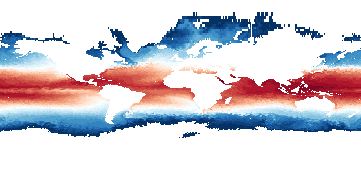

In [24]:
fm